# 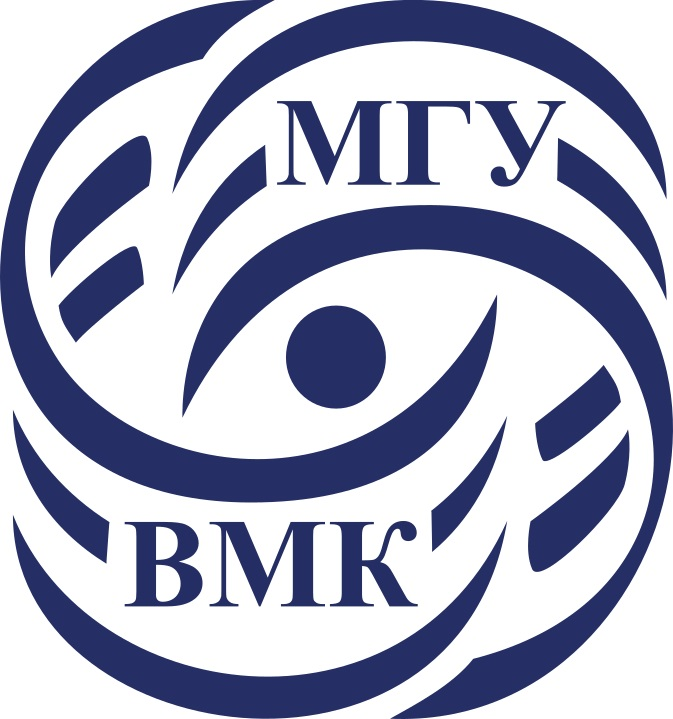

# Машинное обучение. ВМК МГУ

# Практическое задание 6: Линейные модели: классификация

## Уровень: <font color='SkyBlue'>**Базовый (Base)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

-----------
<font color="white" style="opacity:0.2025"></font>







Цель данного задания:

* Узнать, что такое переобучение и как с ним бороться в линейных моделях;
* Научиться работать с разными типами признаков;
* Понять, чем отличаются разные регуляризаторы;
* Приятно провести осенний вечер, предсказывая дождь.

---

<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: до 30 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [1]:
! curl https://raw.githubusercontent.com/MSU-ML-COURSE/ML-COURSE-25-26/refs/heads/master/requirements/requirements.txt -o ./requirements_2025_26_for_colab_small.txt
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   360  100   360    0     0   1396      0 --:--:-- --:--:-- --:--:--  1400


Проверим версию библиотеки:

In [2]:
import catboost
assert(catboost.__version__ == '1.2.8')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

In [3]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.simplefilter("ignore")
sns.set(style="darkgrid")
%matplotlib inline

## Часть 1. Классификация

Напомним, что бинарная линейная классификация с классами $0$ и $1$ &mdash; это модель следующего вида:
$a(x)= \begin{cases}
1, & \langle w, x \rangle + b > 0; \\
0, & \text{иначе.}
\end{cases}$

где  $w \in \mathbb{R}^d$,  $b \in \mathbb{R}$. В логистической регрессии $p(x) = \frac{1}{1 + e^{-[\langle w, x \rangle + b]}}$ интерпретируется как вероятность принадлежности к первому классу. Если объект $x$ принадлежит классу $1$ с вероятностью $p(x)$, то правдоподобие записывается в виде $\prod_{i=1}^{n} p(x_i)^{y_i} \cdot \left( 1 - p(x_i) \right)^{1 - y_i}$. Обучить логистическую регрессию означает найти параметры $w$ и $b$, которые максимизируют указанное правдоподобие. Что эквивалентно минимизации $- \sum_{i=1}^n y_i \log p(x_i) + (1 - y_i) \log (1 - p(x_i))$. Указанная функция потерь называет логистической (или логлосс).

По тем же причинам, что и в линейной регрессии, к логистической функции потерь добавляется регуляризация (стандартно это $l_2$).

### <font color='DarkOrange'>**Задание 1 [1 балл]**</font>

Можно ли использовать  $𝑙_1$  регуляризацию в логистической регрессии?

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Очевидно, да. $l_1$ &mdash; регуляризацию можно и часто даже нужно использовать в логистической регрессии

Давайте рассмотрим модельный пример.

$x_1 \sim Uniform(0, 1)$, $x_2 \sim Uniform(0, 1)$

$y(x_1, x_2)= \begin{cases}
0, & x_1 + x_2 < 5; \\
1, & \text{иначе.}
\end{cases}$

Сгенерируем данные и выучим логистическую регрессию, визуализировав полученный результат.

In [4]:
np.random.seed(1)
X1 = np.random.uniform(0, 5, 100)
X2 = np.random.uniform(0, 5, 100)
X = np.hstack((X1[:, None], X2[:, None]))
Y = np.where(X1 + X2 < 5, 0, 1)

In [5]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(penalty='l2')
clf.fit(X, Y)

LogisticRegression()

In [6]:
from matplotlib.colors import ListedColormap

def plot_separating_surface(X, y, cls, view_support=False):
    x_min = min(X[:, 0]) - 0.1
    x_max = max(X[:, 0]) + 0.1
    y_min = min(X[:, 1]) - 0.1
    y_max = max(X[:, 1]) + 0.1
    h = 0.005
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
    Z = cls.predict(np.c_[xx.ravel(), yy.ravel()])

    plt.figure(figsize=(8, 8))
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=40, cmap=cm_bright)
    if view_support:
        plt.scatter(X[cls.support_, 0], X[cls.support_, 1],
                    c=y[cls.support_], edgecolors='k', s=150, cmap=cm_bright)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cm, alpha=.3)
    plt.title("Визуализация прогнозатора", size=15)
    plt.xlabel(r'$x_1$', size=15)
    plt.ylabel(r'$x_2$', size=15)

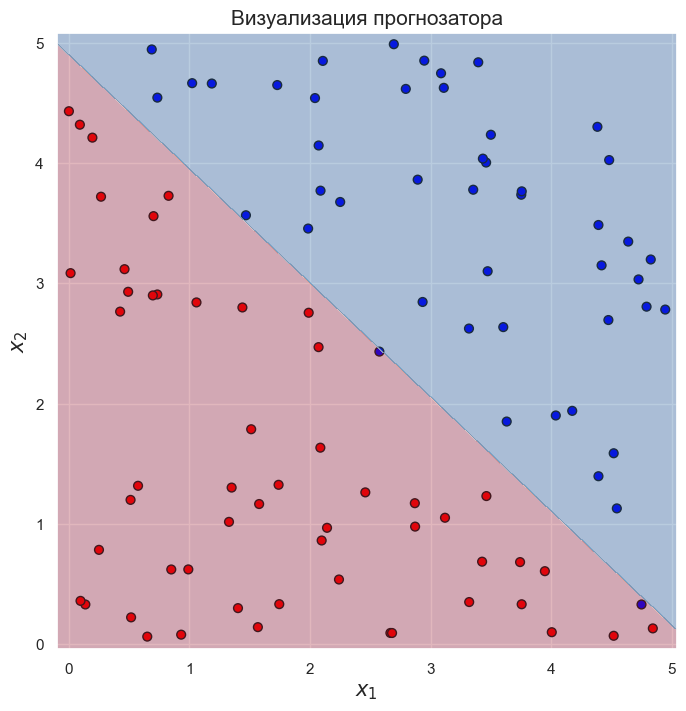

In [7]:
plot_separating_surface(X, Y, clf)

### <font color='DarkOrange'>**Задание 2 [2 баллa]**</font>
Придумайте, сгенерируйте и визуализируйте пример (рекомендуется использовать написанную выше функцию plot_separating_surface), в котором логистическая регрессия будет плохо классифицировать данные.


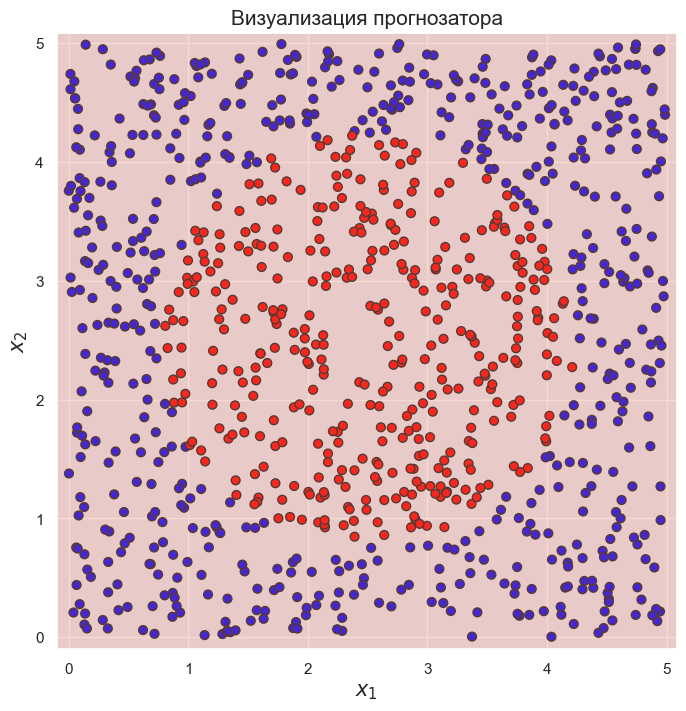

In [8]:
np.random.seed(1)
bad_X1 = np.random.uniform(0, 5, 1000)
bad_X2 = np.random.uniform(0, 5, 1000)
bad_X = np.hstack((bad_X1[:, None], bad_X2[:, None]))
bad_Y = np.where((bad_X1 - 2.5) ** 2 + (bad_X2 - 2.5) ** 2 < 3, 0, 1)

clf = LogisticRegression(penalty='l2')
clf.fit(bad_X, bad_Y)

plot_separating_surface(bad_X, bad_Y, clf)


<font color='MediumOrchid'>**Ваш ответ тут (для доп. комментариев):**</font>

Любая линейная классификация будет некорректна, ибо мои классы линейно неразделимы. Можно преобразовать это например в 3D, взяв параболическую повехность и разделить уже плоскостью

## Обучение на реальных данных

Рассмотрим набор данных от метеорологической службы одной страны. В нём требуется предсказать, будет ли дождь на следующий день.

Для начала, скачаем данные

In [9]:
!gdown 1AgUMxgMK-eRjzthevCk9g-J_s2vpBFpe

Downloading...
From: https://drive.google.com/uc?id=1AgUMxgMK-eRjzthevCk9g-J_s2vpBFpe
To: /home/tepumasuta/devs/university/sem 5/ml/task6/base/weatherAUS.csv
100%|██████████████████████████████████████| 14.1M/14.1M [00:01<00:00, 7.65MB/s]


In [10]:
df = pd.read_csv("./weatherAUS.csv")
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### <font color='DarkOrange'>**Задание 3 [1 балл]**</font>

Что это за страна? Подсказка: жители этой страны воспользовались бы методом tail вместо head :)

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Ахахахааахахах, австралийцы это)

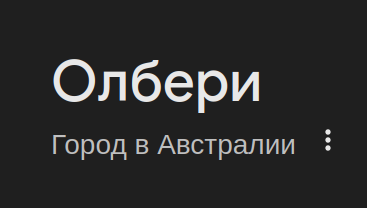

Извлечём немного информации из набора данных

In [11]:
df.shape

(145460, 23)

In [12]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

Внимательно приглядимся к столбцам. Напомним, что мы предсказываем значение RainTomorrow. Давайте посмотрим, на этот столбец

In [13]:
df['RainTomorrow'].unique()

array(['No', 'Yes', nan], dtype=object)

Целевая переменная содержит неопределённые значения! Их нужно удалить из всей выборки. Также, переименуем 'Yes' и 'No' в $1$ и $0$.

In [14]:
df = df[df['RainTomorrow'] == df['RainTomorrow']]
df['RainTomorrow'].unique()

array(['No', 'Yes'], dtype=object)

In [15]:
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1., 'No': 0.})
df['RainToday'] = df['RainToday'].map({'Yes': 1., 'No': 0.})

In [16]:
print(df.shape)

(142193, 23)


Объектов стало чуть-чуть поменьше. Давайте выведем немного информации о них

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   fl

Как видим, у нас есть 17 признаков имеющих вещественные значения (вещественные признаки), и 5 признаков типа object (категориальные признаки). Для них требуется отдельная предобработка. Пока разобьём выборку на обучающую и тестовую.

In [18]:
from sklearn.model_selection import train_test_split

<img src="https://img.devrant.com/devrant/rant/r_2416968_UUKQJ.jpg" width=360 height=760 />

In [19]:
y = df.RainTomorrow
X = df.drop(columns=["RainTomorrow"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [20]:
X_train.shape

(99535, 22)

#### Вещественные признаки

Как вы могли заметить, среди вещественных и категориальных признаков есть пропущенные значения. В случае с вещественными признаками, пропущенные значения заполняют средним, медианой, нулём или даже пытаются предсказывать по другим признакам. Мы заполним медианой

In [21]:
numeric_data = X_train.select_dtypes([np.number])
numeric_data_median = numeric_data.median()
numeric_features = numeric_data.columns
X_train = X_train.fillna(numeric_data_median)
X_test = X_test.fillna(numeric_data_median)

In [22]:
len(numeric_features)

17

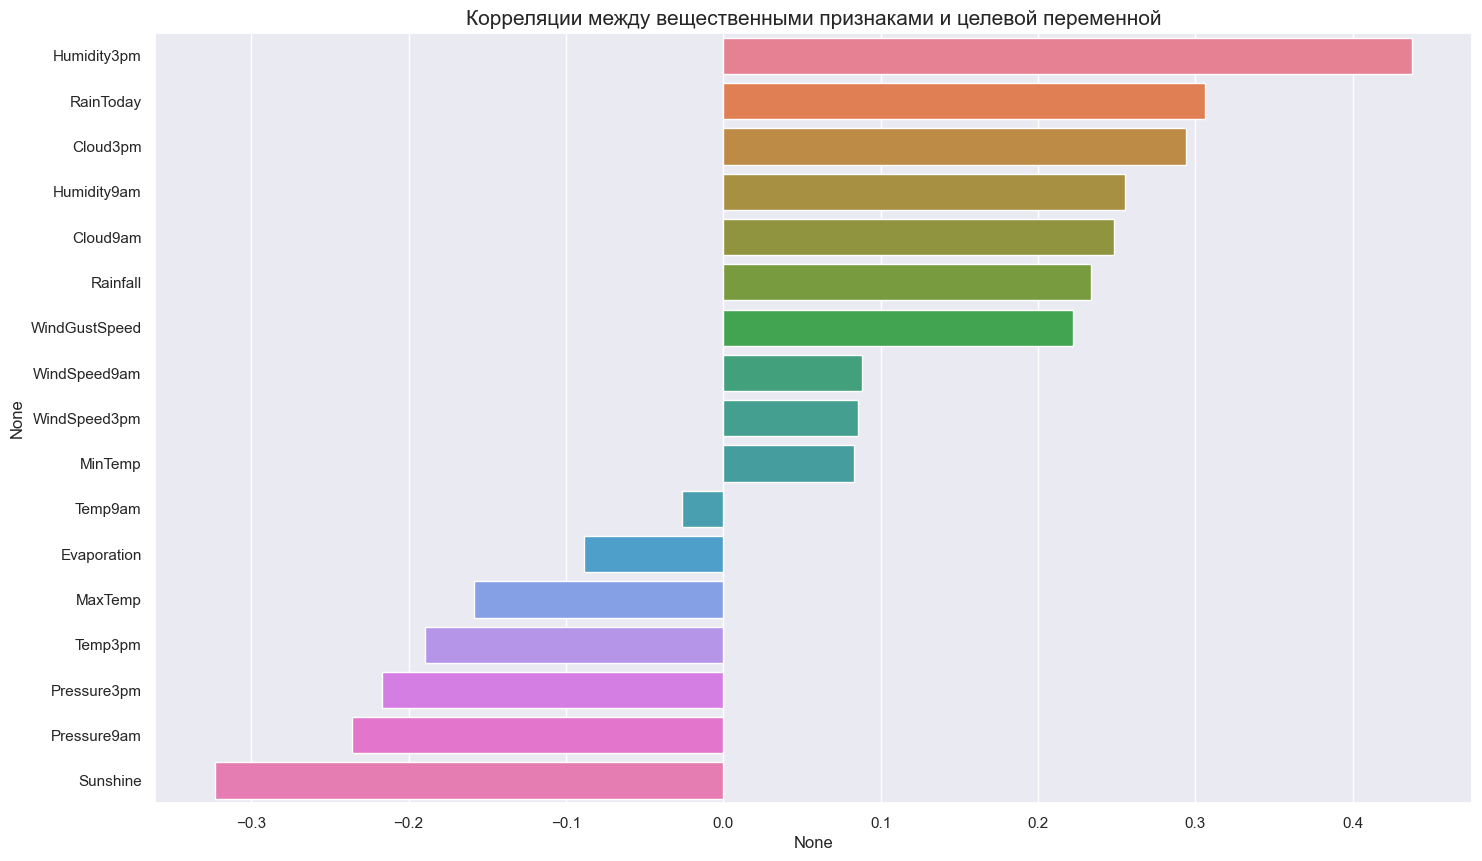

In [23]:
correlations = X_train[numeric_features].corrwith(y_train).sort_values(ascending=False)
plot = sns.barplot(y=correlations.index, x=correlations, palette='husl')
plot.set_title("Корреляции между вещественными признаками и целевой переменной", size=15)
plot.figure.set_size_inches(17, 10)

### <font color='DarkOrange'>**Задание 4 [2 баллa]**</font>

Попробуйте объяснить для каких-нибудь признаков получившиеся значения корреляции (почему для одних эти значения высокие, а для других низкие)?

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Sunshine, сильно отрицательная корреляция, ибо солнечная погода обычно означает хорошие метеоусловия без осадков, ну и следовательно низкое количество осадков, то бишь дождя. Humidity3pm, очень сильно положительная корреляция, ну логично, что если в 15.00 влажно, то скорее всего завтра будет дождь

----

Дополнительно визуализируем признаки Sunshine и Humidity3pm. Библиотека seaborn предоставляет график swarmplot, который в отличие от scatterplot старается разместить на графике как можно больше точек, так чтобы они не пересекались, уложившись при этом в заданную ширину.

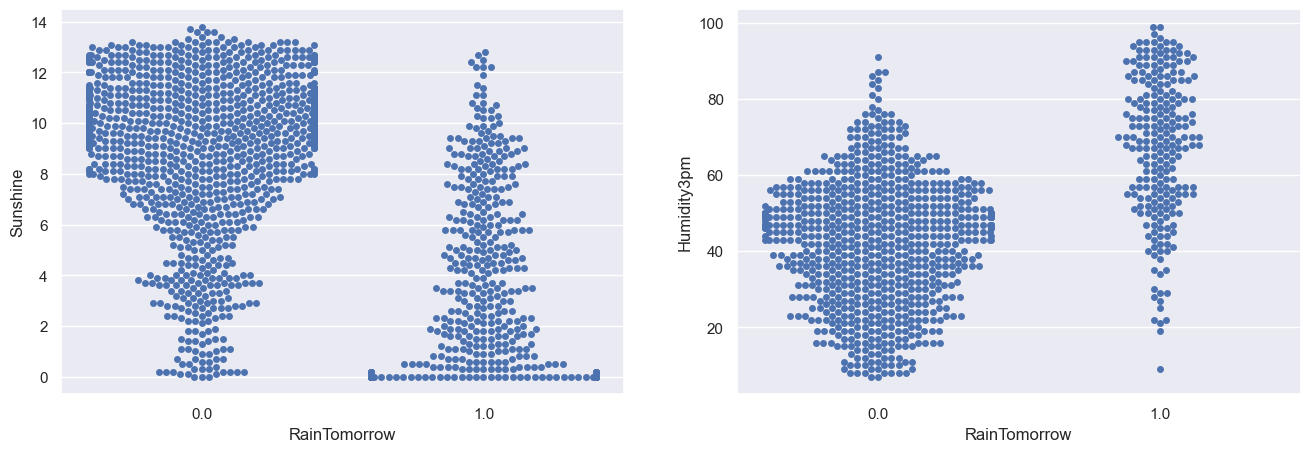

In [24]:
fig, axs = plt.subplots(figsize=(16, 5), nrows=1, ncols=2)
_ = sns.swarmplot(x="RainTomorrow", y="Sunshine", data=df.head(10000), ax=axs[0])
_ = sns.swarmplot(x="RainTomorrow", y="Humidity3pm", data=df.head(1000), ax=axs[1])

Для оценки качества классификации воспользуемся реализованными в sklearn logloss и ROC AUC. ROC AUC является метрикой по умолчанию для бинарной классификации, поскольку очень устойчива к несбалансированности классов. Подробнее про неё можно прочитать https://alexanderdyakonov.wordpress.com/2017/07/28/auc-roc-площадь-под-кривой-ошибок/ . Обучим  логистическую регрессию на вещественных признаках, не подбирая константу регуляризации

In [25]:
from sklearn.metrics import log_loss, roc_auc_score

In [26]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train[numeric_features], y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict_proba(X_test[numeric_features])[:, 1]
y_train_pred = model.predict_proba(X_train[numeric_features])[:, 1]

print("Test logloss = %.4f" % log_loss(y_test, y_pred))
print("Train logloss = %.4f" % log_loss(y_train, y_train_pred))
print("Test roc auc score = %.4f" % roc_auc_score(y_test, y_pred))
print("Train roc auc score = %.4f" % roc_auc_score(y_train, y_train_pred))

Test logloss = 0.3635
Train logloss = 0.3695
Test roc auc score = 0.8604
Train roc auc score = 0.8564


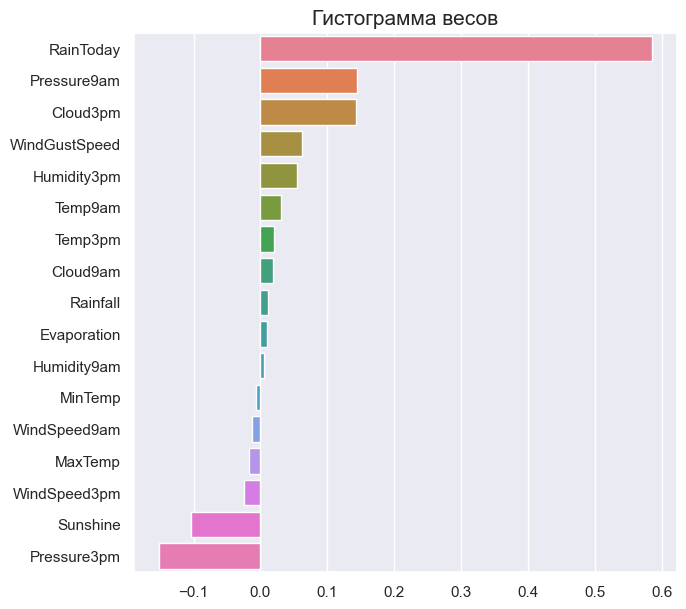

In [28]:
plt.figure(figsize=(7, 7))
sorted_weights = sorted(zip(model.coef_[0], numeric_features), reverse=True)
weights = [x[0] for x in sorted_weights]
features = [x[1] for x in sorted_weights]
_ = sns.barplot(y=features, x=weights, palette='husl').set_title("Гистограмма весов", size=15)

Если приглядеться к весам, то можно увидеть, что между корреляциями признаков с целевой переменной и значением соответствующих весов мало общего. Чтобы это предотвратить, будем масштабировать наши признаки перед обучением модели. Это, среди, прочего, сделает нашу регуляризацию более честной: теперь все признаки будут регуляризоваться в равной степени.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

In [30]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [31]:
y_pred = model.predict_proba(X_test_scaled)[:, 1]
y_train_pred = model.predict_proba(X_train_scaled)[:, 1]

print("Test logloss = %.4f" % log_loss(y_test, y_pred))
print("Train logloss = %.4f" % log_loss(y_train, y_train_pred))
print("Test roc auc score = %.4f" % roc_auc_score(y_test, y_pred))
print("Train roc auc score = %.4f" % roc_auc_score(y_train, y_train_pred))

Test logloss = 0.3589
Train logloss = 0.3637
Test roc auc score = 0.8652
Train roc auc score = 0.8623


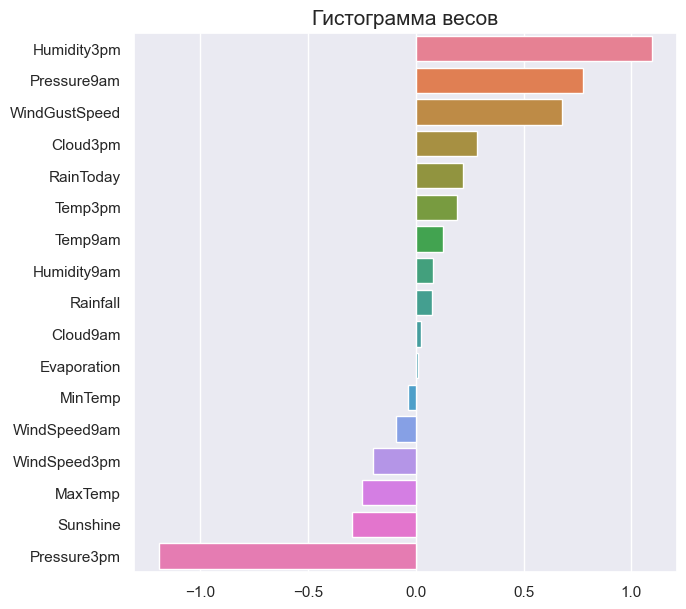

In [32]:
plt.figure(figsize=(7, 7))
sorted_weights = sorted(zip(model.coef_[0], numeric_features), reverse=True)
weights = [x[0] for x in sorted_weights]
features = [x[1] for x in sorted_weights]
_ = sns.barplot(y=features, x=weights, palette='husl').set_title("Гистограмма весов", size=15)

### <font color='DarkOrange'>**Задание 5 [1 балл]**</font>

Почему даже после нормализации график не до конца похож на гистограмму корреляций?

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Ну как минимум существует мультиколлинеарность, которая попарно ведёт себя одним образом (при корреляции), а вот при логистической регрессии, которая одновременно все признаки рассматривает и тем более с учётом регуляризации конечно мы штрафуем за такую пакость и имеем другое распределние весов, да и к тому же, они моделируют даже разные, коэффициенты корреляции и логистическая вероятность конечно что-то общее имеют, но являются разными объектами

Рассмотрим теперь категориальные признаки. Сразу отметим, что признак "Date" очень опасен, и лучше пока его выкинуть. Это связано с тем, что мы можем получить прямую информацию о том, будет ли завтра дождь, если текущее место и завтрашняя дата встречались где-то в обучающей выборке. Очень часто также встречаются признак наподобие "ID", которые могут содержать аналогичные утечки информации. С такими признаками всегда нужно обращаться осторожно!

In [33]:
categorical = list(X_train.drop(columns=["Date"]).dtypes[X_train.dtypes == "object"].index)
X_train[categorical] = X_train[categorical].fillna("NotGiven")
X_test[categorical] = X_test[categorical].fillna("NotGiven")

Для работы с категориальными признаками нужно их как-то закодировать числами. Для этого воспользуемся реализацией one-hot кодирования из библиотеки sklearn

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[
    ('ohe', column_transformer),
    ('classification', LogisticRegression(solver='lbfgs', max_iter=200))
])

model = pipeline.fit(X_train.drop(columns=["Date"]), y_train)
y_pred = model.predict_proba(X_test.drop(columns=["Date"]))[:, 1]
print("Test logloss = %.4f" % log_loss(y_test, y_pred))
print("Test roc auc score = %.4f" % roc_auc_score(y_test, y_pred))

Test logloss = 0.3498
Test roc auc score = 0.8721


In [35]:
model.named_steps['classification'].n_iter_

array([44], dtype=int32)

Качество немного выросло, если смотреть на ROC AUC!

### <font color='DarkOrange'>**Задание 6 [1 балл]**</font>

Почему итоговое качество выросло?

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Качество выросло потому, что категориальные признаки несли дополнительную информацию, не содержащуюся в вещественных признаках, One-hot кодирование позволило модели учесть эти категориальные признаки, что и привело к улучшению качества. Однако, стоит отметить, что мы также заменили пропуски в категориальных признаках на строку "NotGiven", что тоже сказалось, т.к. пропуски в категориальных признаках могут нести информацию, ну и таким образом, улучшение качества связано с тем, что модель теперь использует больше информации из данных. А улучшился в основном ROC AUC, т.к. эта метрика особенно чувствительна к улучшениям в ранжировании вероятностей

### <font color='DarkOrange'>**Задание 7 [2 баллa]**</font>

Попробуйте улучшить качество модели, попробовав другие гиперпараметры (например, число итераций, метод оптимизации, константу регуляризации и т.д.). Измерьте получившийся результат и напишите, благодаря чему удалось или не удалось улучшить текущие метрики

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

param_grid = [
    {
        'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'max_iter': [10, 100, 200, 500, 1000, 1500],
        'penalty': ['l2', 'l1'],
    },
]

pipeline = make_pipeline(
    column_transformer,
    GridSearchCV(
        LogisticRegression(random_state=69),
        param_grid,
        scoring='roc_auc',
        cv=3,
        n_jobs=-1,
        verbose=10,
        refit=True
    )
)

warnings.filterwarnings('ignore')

pipeline.fit(X_train, y_train)


Fitting 3 folds for each of 288 candidates, totalling 864 fits
[CV 1/3; 1/288] START C=0.0001, max_iter=10, penalty=l2, solver=lbfgs...........
[CV 1/3; 1/288] END C=0.0001, max_iter=10, penalty=l2, solver=lbfgs;, score=0.848 total time=   0.2s
[CV 2/3; 1/288] START C=0.0001, max_iter=10, penalty=l2, solver=lbfgs...........
[CV 3/3; 3/288] START C=0.0001, max_iter=10, penalty=l2, solver=saga............
[CV 3/3; 1/288] START C=0.0001, max_iter=10, penalty=l2, solver=lbfgs...........
[CV 2/3; 1/288] END C=0.0001, max_iter=10, penalty=l2, solver=lbfgs;, score=0.850 total time=   0.3s
[CV 1/3; 4/288] START C=0.0001, max_iter=10, penalty=l1, solver=lbfgs...........
[CV 3/3; 1/288] END C=0.0001, max_iter=10, penalty=l2, solver=lbfgs;, score=0.854 total time=   0.2s
[CV 1/3; 3/288] START C=0.0001, max_iter=10, penalty=l2, solver=saga............
[CV 1/3; 4/288] END C=0.0001, max_iter=10, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/3; 4/288] START C=0.0001, max_iter=10, pena

/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 1/3; 37/288] END C=0.001, max_iter=10, penalty=l2, solver=lbfgs;, score=0.859 total time=   0.2s
[CV 2/3; 37/288] START C=0.001, max_iter=10, penalty=l2, solver=lbfgs...........
[CV 3/3; 27/288] END C=0.0001, max_iter=1000, penalty=l2, solver=saga;, score=0.854 total time=  23.2s
[CV 3/3; 37/288] START C=0.001, max_iter=10, penalty=l2, solver=lbfgs...........


/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

[CV 2/3; 37/288] END C=0.001, max_iter=10, penalty=l2, solver=lbfgs;, score=0.863 total time=   0.2s
[CV 1/3; 38/288] START C=0.001, max_iter=10, penalty=l2, solver=liblinear.......
[CV 3/3; 37/288] END C=0.001, max_iter=10, penalty=l2, solver=lbfgs;, score=0.864 total time=   0.3s
[CV 2/3; 38/288] START C=0.001, max_iter=10, penalty=l2, solver=liblinear.......
[CV 1/3; 38/288] END C=0.001, max_iter=10, penalty=l2, solver=liblinear;, score=0.860 total time=   0.7s
[CV 3/3; 38/288] START C=0.001, max_iter=10, penalty=l2, solver=liblinear.......
[CV 2/3; 38/288] END C=0.001, max_iter=10, penalty=l2, solver=liblinear;, score=0.863 total time=   0.8s
[CV 1/3; 39/288] START C=0.001, max_iter=10, penalty=l2, solver=saga............
[CV 3/3; 30/288] END C=0.0001, max_iter=1000, penalty=l1, solver=saga;, score=0.792 total time=  18.8s
[CV 2/3; 39/288] START C=0.001, max_iter=10, penalty=l2, solver=saga............
[CV 3/3; 38/288] END C=0.001, max_iter=10, penalty=l2, solver=liblinear;, score=

...

[CV 1/3; 77/288] END C=0.01, max_iter=10, penalty=l1, solver=liblinear;, score=0.859 total time=   0.6s
[CV 2/3; 77/288] START C=0.01, max_iter=10, penalty=l1, solver=liblinear........


/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV 2/3; 77/288] END C=0.01, max_iter=10, penalty=l1, solver=liblinear;, score=0.864 total time=   0.6s
[CV 3/3; 77/288] START C=0.01, max_iter=10, penalty=l1, solver=liblinear........
[CV 3/3; 75/288] END C=0.01, max_iter=10, penalty=l2, solver=saga;, score=0.871 total time=   2.1s
[CV 1/3; 78/288] START C=0.01, max_iter=10, penalty=l1, solver=saga.............


/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV 3/3; 77/288] END C=0.01, max_iter=10, penalty=l1, solver=liblinear;, score=0.864 total time=   0.7s
[CV 2/3; 78/288] START C=0.01, max_iter=10, penalty=l1, solver=saga.............
[CV 1/3; 78/288] END C=0.01, max_iter=10, penalty=l1, solver=saga;, score=0.861 total time=   1.6s
[CV 3/3; 78/288] START C=0.01, max_iter=10, penalty=l1, solver=saga.............
[CV 2/3; 78/288] END C=0.01, max_iter=10, penalty=l1, solver=saga;, score=0.865 total time=   1.6s
[CV 1/3; 79/288] START C=0.01, max_iter=100, penalty=l2, solver=lbfgs...........
[CV 1/3; 79/288] END C=0.01, max_iter=100, penalty=l2, solver=lbfgs;, score=0.866 total time=   0.7s
[CV 2/3; 79/288] START C=0.01, max_iter=100, penalty=l2, solver=lbfgs...........
[CV 3/3; 78/288] END C=0.01, max_iter=10, penalty=l1, solver=saga;, score=0.866 total time=   1.6s
[CV 3/3; 79/288] START C=0.01, max_iter=100, penalty=l2, solver=lbfgs...........
[CV 2/3; 79/288] END C=0.01, max_iter=100, penalty=l2, solver=lbfgs;, score=0.870 total time=

In [ ]:
pipeline.predict_proba(X_test)[:, 1]

array([0.1945748 , 0.17789121, 0.0741862 , ..., 0.12692366, 0.19847864,
       0.39536767])

In [ ]:
best_logloss = log_loss(y_test, pipeline.predict_proba(X_test)[:, 1])
best_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])

print(f'Лучшая модель be like:')
print(f'Лучшие параметры: {pipeline._final_estimator.best_params_}')
print(f'Test logloss = {best_logloss:.4f}')
print(f'Test ROC AUC = {best_auc:.4f}')

Лучшая модель be like:
Лучшие параметры: {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}
Test logloss = 0.3498
Test ROC AUC = 0.8722


In [ ]:
results_df = pd.DataFrame(pipeline._final_estimator.cv_results_)

In [ ]:
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_max_iter,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.149146,0.005924,0.019406,0.000845,0.0001,10,l2,lbfgs,"{'C': 0.0001, 'max_iter': 10, 'penalty': 'l2',...",0.848258,0.850487,0.853501,0.850749,0.002149,223
1,0.471463,0.019489,0.019655,0.002709,0.0001,10,l2,liblinear,"{'C': 0.0001, 'max_iter': 10, 'penalty': 'l2',...",0.849852,0.851860,0.854985,0.852232,0.002112,211
2,1.274287,0.006788,0.019507,0.000817,0.0001,10,l2,saga,"{'C': 0.0001, 'max_iter': 10, 'penalty': 'l2',...",0.848789,0.850960,0.854008,0.851252,0.002140,217
3,0.021520,0.001796,0.000000,0.000000,0.0001,10,l1,lbfgs,"{'C': 0.0001, 'max_iter': 10, 'penalty': 'l1',...",NaN,NaN,NaN,NaN,NaN,241
4,0.193810,0.018828,0.018151,0.002338,0.0001,10,l1,liblinear,"{'C': 0.0001, 'max_iter': 10, 'penalty': 'l1',...",0.786330,0.796311,0.792244,0.791628,0.004098,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,1.273330,0.024848,0.025218,0.003346,1000.0000,1500,l2,liblinear,"{'C': 1000, 'max_iter': 1500, 'penalty': 'l2',...",0.867308,0.870381,0.871895,0.869862,0.001908,96
284,13.772028,0.128662,0.023609,0.002864,1000.0000,1500,l2,saga,"{'C': 1000, 'max_iter': 1500, 'penalty': 'l2',...",0.867308,0.870382,0.871895,0.869862,0.001908,82
285,0.016526,0.002525,0.000000,0.000000,1000.0000,1500,l1,lbfgs,"{'C': 1000, 'max_iter': 1500, 'penalty': 'l1',...",NaN,NaN,NaN,NaN,NaN,241
286,2.751010,0.051691,0.026038,0.002878,1000.0000,1500,l1,liblinear,"{'C': 1000, 'max_iter': 1500, 'penalty': 'l1',...",0.867306,0.870380,0.871896,0.869861,0.001910,117


In [ ]:
top_results = results_df.nlargest(5, 'mean_test_score')
print('Топ-5 дай пять комбинаций параметров:')
print(*zip(top_results.mean_test_score.to_list(), top_results.params.to_list()), sep='\n')

Топ-5 дай пять комбинаций параметров:
(0.8699414341722737, {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'})
(0.8699409509008706, {'C': 0.1, 'max_iter': 200, 'penalty': 'l2', 'solver': 'saga'})
(0.869939302914486, {'C': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga'})
(0.869937308994241, {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'})
(0.8699350734404908, {'C': 0.1, 'max_iter': 1500, 'penalty': 'l2', 'solver': 'saga'})


<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Судя по всему, модель переобучается, т.к. при уменьшении числа итераций, то бишь менее точной подгонки, roc_auc_score немного возрос, и это единственное, что получилось, перебор других оптимизаторов не помог, да и вероятно вряд ли бы мог, тем более если они сходятся лучше, т.к. дело вероятно в переобучении. Грубо говоря, уменьшение максимального числа итераций выступает в роли своего рода регуляризатором, который позволяет лучше найти оптимальную модель

**Выводы** Во второй части задания по линейным моделям мы должны были узнать:
.

1.   Зачем нужно нормализовать данные.
2.   Как работать с вещественными и категориальными признаками.
3.   Как интерпретировать результат обучения линейной модели, опираясь на описание обучающих данных

-----------
<font color="white" style="opacity:0.2025"></font>

## <font color='MediumSeaGreen'> **Задание [Bonus][2 балла]** </font>

Вставьте мем или красивую картинку связанные с чем-то из:


1.   Страна, данные о которой мы анализировали
2.   Линейные модели
3.   Погода
4.   Динозавры

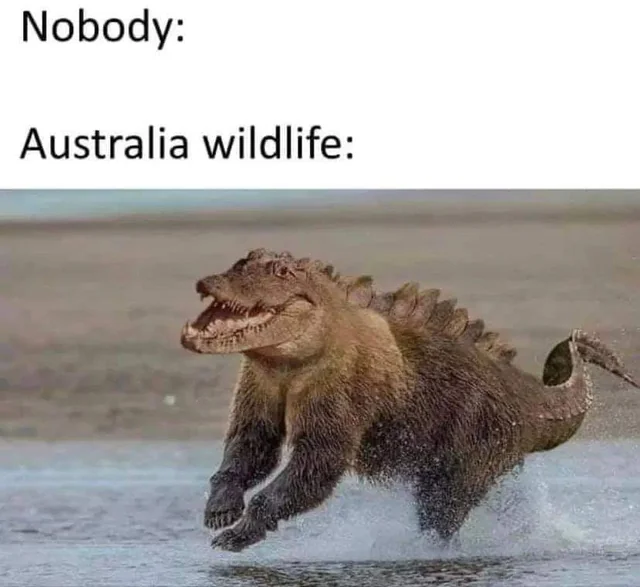